# Higgs 衰變頻道 CWoLa 直接訓練與 Transfer Learning 比較繪圖

本 Notebook 讀取 `/home/r10222035/NTUHEPML-CWoLa/output/inference` 的精確推理結果 CSV，繪製出版級對比圖。
標準差計算方式採用 95% 信心區間半寬度 (95% CI half-width = 1.96 * SEM)。


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

# 強制使用絕對路徑，定位推斷數據與圖表目錄
ROOT = Path("/home/r10222035/NTUHEPML-CWoLa")
INFERENCE_DIR = ROOT / "output" / "inference"
FIGURES_DIR = Path("./figures/paper")
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Inference Directory: {INFERENCE_DIR}")
print(f"  Exists: {INFERENCE_DIR.exists()}")
print(f"Figures Directory: {FIGURES_DIR}")


Inference Directory: /home/r10222035/NTUHEPML-CWoLa/output/inference
  Exists: True
Figures Directory: figures/paper


## 1. 讀取數據與定義輔助函數


In [2]:
def load_inference_results(sub_dir_name):
    dir_path = INFERENCE_DIR / sub_dir_name
    if not dir_path.exists():
        print(f"[Notice] Directory {dir_path} does not exist yet (or no runs completed).")
        return pd.DataFrame()
    
    dfs = []
    for csv_file in dir_path.glob("*.csv"):
        df = pd.read_csv(csv_file)
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    res = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(dfs)} CSV files from {sub_dir_name} (Total rows: {len(res)})")
    return res

# 讀取各組推理數據
df_trans_zz = load_inference_results("transfer_from_diphoton_to_zz4l")
df_trans_za = load_inference_results("transfer_from_diphoton_to_za2l")
df_direct_zz = load_inference_results("direct_zz4l")
df_direct_za = load_inference_results("direct_za2l")

# 讀取備用 summary 結果 (若有)
try:
    df_cnn_direct = pd.read_csv('./CNN/GGF_VBF_training_results.csv')
    df_part_direct = pd.read_csv('./Particle_transformer/GGF_VBF_training_results.csv')
    df_summary = pd.read_csv('./GGF_VBF_CWoLa_summary.csv')
except Exception:
    df_cnn_direct = pd.DataFrame()
    df_part_direct = pd.DataFrame()
    df_summary = pd.DataFrame()

def get_auc_summary(df, model_name, num_rot_aug):
    """回傳 mean 與 95% CI half-width (= 1.96 * SEM)，與 seaborn.lineplot 預設行為一致。"""
    if df is None or df.empty:
        return [None]*5, [None]*5
    lumi_list = [100, 300, 900, 1800, 3000]
    means, ci95s = [], []
    target_aug = str(num_rot_aug).replace("+", "").strip()
    sub_df = df[(df["model"] == model_name) & (df["num_rot_aug"].astype(str).str.replace("+", "", regex=False).str.strip() == target_aug)]
    for l in lumi_list:
        vals = sub_df[sub_df["luminosity"] == l]["test_auc"].dropna()
        if len(vals) == 0:
            means.append(None)
            ci95s.append(None)
        else:
            n = len(vals)
            std = vals.std()          # ddof=1 (sample std)
            sem = std / np.sqrt(n)     # standard error of mean
            means.append(vals.mean())
            ci95s.append(1.96 * sem)  # 95% CI half-width
    return means, ci95s

def get_direct_AUC_and_error(df, sample_type_template, luminosity):
    if df is None or df.empty:
        return 0.5, 0.0
    sample_type = sample_type_template.format(luminosity)
    df_sub = df[df['Sample Type'] == sample_type]
    vals = df_sub['AUC-true'].dropna()
    if len(vals) == 0:
        return 0.5, 0.0
    n = len(vals)
    sem = vals.std() / np.sqrt(n)
    return vals.mean(), 1.96 * sem

def get_transfer_AUC_and_error(df, model_type, name_pattern, luminosity, column_name):
    if df is None or df.empty:
        return 0.5, 0.0
    df_sub = df[(df['Model type'] == model_type) & (df['Luminosity (fb^-1)'] == luminosity)]
    if name_pattern == 'original':
        df_sub = df_sub[~df_sub['Model Name'].str.contains('phi_aug')]
    else:
        df_sub = df_sub[df_sub['Model Name'].str.contains(name_pattern)]
    
    vals = df_sub[column_name].dropna()
    if len(vals) == 0:
        return 0.5, 0.0
    n = len(vals)
    sem = vals.std() / np.sqrt(n)
    return vals.mean(), 1.96 * sem


Loaded 6 CSV files from transfer_from_diphoton_to_zz4l (Total rows: 300)
Loaded 6 CSV files from transfer_from_diphoton_to_za2l (Total rows: 300)
Loaded 6 CSV files from direct_zz4l (Total rows: 300)
Loaded 6 CSV files from direct_za2l (Total rows: 300)


## 2. 定義統一繪圖函數


In [3]:
def get_auc_summary(df, model_name, num_rot_aug, channel_title=None, is_direct=False):
    """回傳 mean 與 95% CI half-width (= 1.96 * SEM)。
    若 inference df 中無數據，則嘗試自動從本地 training_results.csv 讀取。"""
    lumi_list = [100, 300, 900, 1800, 3000]
    means, ci95s = [], []
    target_aug = str(num_rot_aug).replace("+", "").strip()
    
    if df is not None and not df.empty and "model" in df.columns:
        sub_df = df[(df["model"] == model_name) & (df["num_rot_aug"].astype(str).str.replace("+", "", regex=False).str.strip() == target_aug)]
        for l in lumi_list:
            vals = sub_df[sub_df["luminosity"] == l]["test_auc"].dropna()
            if len(vals) == 0:
                means.append(None)
                ci95s.append(None)
            else:
                n = len(vals)
                std = vals.std()
                sem = std / np.sqrt(n) if n > 1 else 0
                means.append(vals.mean())
                ci95s.append(1.96 * sem)
        if any(x is not None for x in means):
            return means, ci95s

    # 若 inference df 無數據，嘗試從本地 GGF_VBF_training_results.csv 讀取 (例如 CNN Za2l Direct)
    if is_direct and "CNN" in model_name and channel_title in ["Za", "Za2l"]:
        df_csv = df_cnn_direct
        aug_suffix = "" if target_aug in ["0", ""] else f", phi shifting: +{target_aug}"
        for l in lumi_list:
            st = f"quark jet: = 2, L: {l} fb^-1, Za2l, w/o decay product{aug_suffix}"
            vals = df_csv[df_csv['Sample Type'] == st]['AUC-true'].dropna() if not df_csv.empty else []
            if len(vals) == 0:
                means.append(None)
                ci95s.append(None)
            else:
                n = len(vals)
                std = vals.std()
                sem = std / np.sqrt(n) if n > 1 else 0
                means.append(vals.mean())
                ci95s.append(1.96 * sem)
        return means, ci95s

    return [None]*5, [None]*5

def plot_comparison_chart(
    model_name,          # "CNN_EventCNN" 或 "ParT_Light"
    channel_title,       # "ZZ" 或 "Za"
    df_transfer,         # Transfer 數據集 DataFrame
    df_direct,           # Direct 數據集 DataFrame
    save_filename,       # 存檔檔名
    ylim=(0.46, 0.77),
    title_suffix=""
):
    sns.set_theme(style="darkgrid")
    fig, ax = plt.subplots(figsize=(5, 4))
    
    x_vals = np.array([100, 300, 900, 1800, 3000])
    x_labels = ["100", "300", "900", "1800", "3000"]
    
    colors = {
        "+0": "#4C72B0",   # 藍色 (Original)
        "+5": "#DD8452",   # 橘色 (+5 Rotation Aug)
        "+10": "#55A868"   # 綠色 (+10 Rotation Aug)
    }
    markers = {"+0": "o", "+5": "X", "+10": "s"}
    
    def draw_curve(mean, std, label, color, linestyle, marker):
        valid_indices = [i for i, m in enumerate(mean) if m is not None]
        if not valid_indices:
            print(f"  [Notice] No valid AUC data for curve: {label}")
            return
        valid_x = x_vals[valid_indices]
        valid_mean = np.array([mean[i] for i in valid_indices])
        valid_std = np.array([std[i] for i in valid_indices])
        
        ax.plot(valid_x, valid_mean, linestyle=linestyle, marker=marker, markersize=6, color=color,
                label=label, markeredgecolor="w", markeredgewidth=1 if marker in ["o", "X", "s"] else 0)
        if len(valid_x) > 1:
            ax.fill_between(valid_x, valid_mean - valid_std, valid_mean + valid_std, color=color, alpha=0.15)
            
    # 1. 取得與繪製 Transfer 數據 (實線)
    has_transfer_data = False
    for aug in ["+0", "+5", "+10"]:
        m, s = get_auc_summary(df_transfer, model_name, aug, channel_title=channel_title, is_direct=False)
        if any(x is not None for x in m):
            has_transfer_data = True
        draw_curve(m, s, f"Transfer {aug}", colors[aug], "-", markers[aug])
        
    # 2. 取得與繪製 Direct 數據 (虛線)
    has_direct_data = False
    for aug in ["+0", "+5", "+10"]:
        m, s = get_auc_summary(df_direct, model_name, aug, channel_title=channel_title, is_direct=True)
        if any(x is not None for x in m):
            has_direct_data = True
        draw_curve(m, s, f"Direct {aug}", colors[aug], "--", markers[aug])
            
    ax.set_xscale("log")
    ax.set_xlim(80, 3800)
    ax.set_ylim(ylim)
    ax.set_xticks(x_vals)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Luminosity [fb$^{-1}$]", fontsize=12)
    ax.set_ylabel("AUC", fontsize=12)
    
    h_orig = mlines.Line2D([], [], color=colors["+0"], marker="o", linestyle="-", label="Original", markersize=6, markeredgecolor="w", markeredgewidth=1)
    h_aug5 = mlines.Line2D([], [], color=colors["+5"], marker="X", linestyle="-", label="Augment +5", markersize=6, markeredgecolor="w", markeredgewidth=1)
    h_aug10 = mlines.Line2D([], [], color=colors["+10"], marker="s", linestyle="-", label="Augment +10", markersize=6, markeredgecolor="w", markeredgewidth=1)
    h_transfer = mlines.Line2D([], [], color="gray", linestyle="-", label="Transfer")
    h_direct = mlines.Line2D([], [], color="gray", linestyle="--", label="Direct")
    
    handles = [h_orig, h_transfer, h_aug5, h_direct, h_aug10] if has_direct_data else [h_orig, h_aug5, h_aug10, h_transfer]
    ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=8.5, ncol=2 if not has_direct_data else 3, columnspacing=0.8, handletextpad=0.3)
    
    plt.tight_layout()
    pdf_path = FIGURES_DIR / save_filename
    png_path = FIGURES_DIR / save_filename.replace(".pdf", ".png")
    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
    plt.savefig(png_path, format="png", bbox_inches="tight")
    print(f"Saved figures: {pdf_path.name}, {png_path.name}")
    plt.show()
    plt.close(fig)



## 3. 繪製並儲存對比圖


Saved figures: AUC_transfer_zz4l_CNN.pdf, AUC_transfer_zz4l_CNN.png


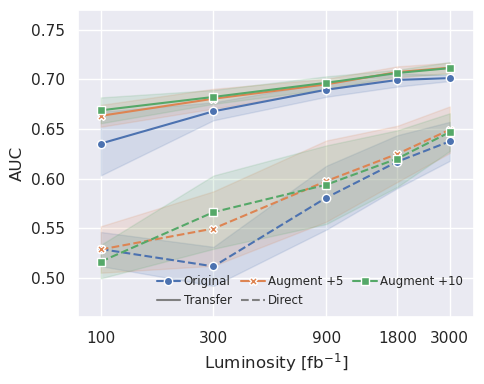

Saved figures: AUC_transfer_za2l_CNN.pdf, AUC_transfer_za2l_CNN.png


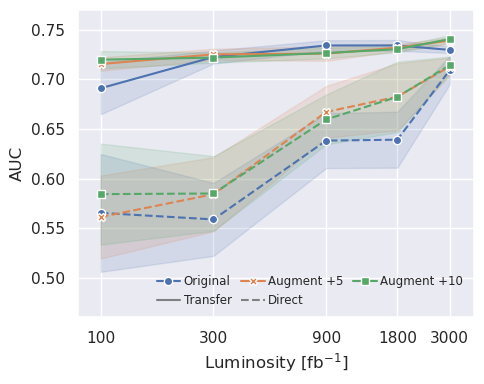

Saved figures: AUC_transfer_zz4l_ParT.pdf, AUC_transfer_zz4l_ParT.png


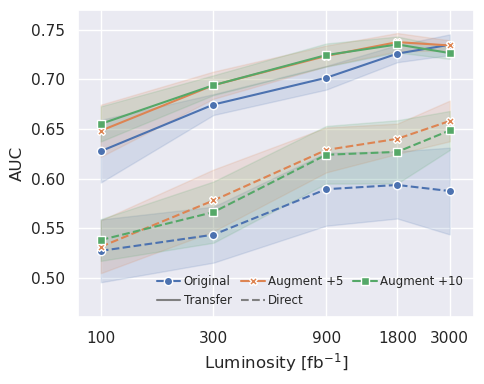

Saved figures: AUC_transfer_za2l_ParT.pdf, AUC_transfer_za2l_ParT.png


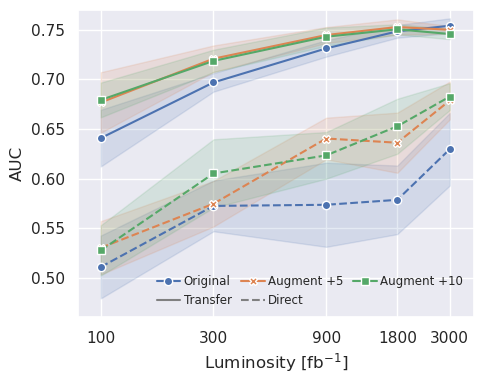

In [4]:
# ==========================================
# 繪圖調用 (4 個對比圖 - 純動態數據載入)
# ==========================================

# (1) Event-CNN in ZZ Channel
plot_comparison_chart("CNN_EventCNN", "ZZ", df_trans_zz, df_direct_zz, "AUC_transfer_zz4l_CNN.pdf")

# (2) Event-CNN in Za Channel
plot_comparison_chart("CNN_EventCNN", "Za", df_trans_za, df_direct_za, "AUC_transfer_za2l_CNN.pdf")

# (3) ParT in ZZ Channel
plot_comparison_chart("ParT_Light", "ZZ", df_trans_zz, df_direct_zz, "AUC_transfer_zz4l_ParT.pdf")

# (4) ParT in Za Channel
plot_comparison_chart("ParT_Light", "Za", df_trans_za, df_direct_za, "AUC_transfer_za2l_ParT.pdf")

